In [155]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

from tabpfn import TabPFNClassifier, TabPFNRegressor
import pandas as pd
import shap as shap

# Load data
file_path = 'cleaned_new.csv'
data = pd.read_csv(file_path)

In [156]:
import numpy as np

# Divide data into 4 equal parts
data_parts = np.array_split(data, 4)

In [157]:
# data_parts[1]['fraction'] = 1

# data_parts[1]['fraction'] = data['label'].apply(lambda x: 0 if x == 1 else 1)

for part in data_parts:
    part['fraction'] = part['grainAreas'] / data_parts[0]['grainAreas'].values
    part.loc[part['label'] == 1, 'fraction'] = 0

# # Remove all rows with label = 1
# for i, part in enumerate(data_parts):
#     data_parts[i] = part[part['label'] != 1]

# Combine all parts into a single dataframe
combined_data = pd.concat(data_parts)
combined_data = combined_data[combined_data['label'] != 1]

# Clip the 'fraction' column to a maximum value of 1
combined_data['fraction'] = combined_data['fraction'].clip(upper=1)


In [158]:
# import seaborn as sns

# import matplotlib.pyplot as plt

# # Plot the distribution of the 'fraction' column for different data parts
# plt.figure(figsize=(10, 6))
# colors = ['blue', 'green', 'red', 'purple']
# for i, part in enumerate(data_parts):
#     sns.histplot(part['fraction'], kde=True, color=colors[i], label=f'Part {i+1}', alpha=0.5)
# plt.xlim(0, 2)
# plt.xlabel('Fraction')
# plt.ylabel('Frequency')
# plt.title('Distribution of Fraction for Different Data Parts')
# plt.legend()
# plt.show()

In [159]:
print(combined_data['label'].value_counts())

label
0    996
Name: count, dtype: int64


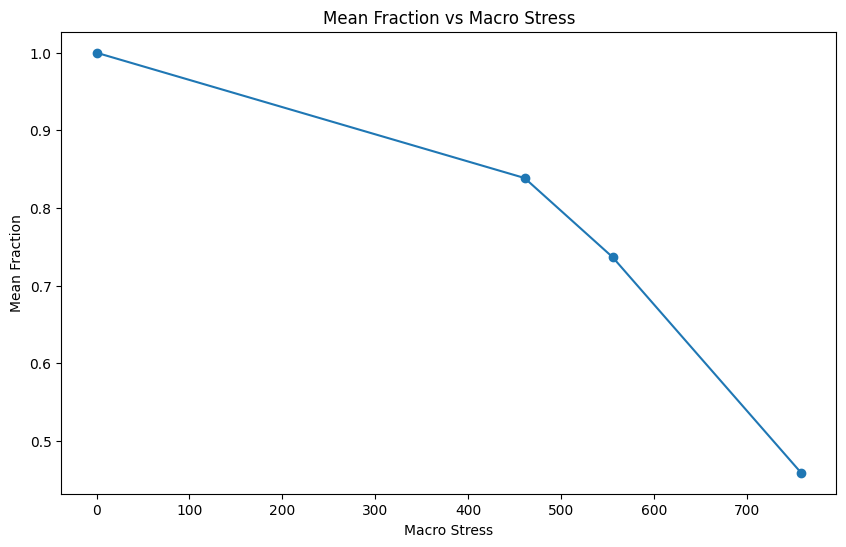

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the 'fraction' column against different features
# plt.figure(figsize=(10, 6))
# plt.scatter(combined_data['Surroun_max_strain'], combined_data['fraction'], alpha=0.5)
# plt.xlabel('Surroun_max_strain')
# plt.ylabel('Fraction')
# plt.title('Scatter Plot of Fraction vs Surrounding Strain')
# plt.show()

# Plot the mean value of 'fraction' for the same 'macro_strain'
mean_fraction = combined_data.groupby('macro_stress')['fraction'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(mean_fraction['macro_stress'], mean_fraction['fraction'], marker='o', linestyle='-')
plt.xlabel('Macro Stress')
plt.ylabel('Mean Fraction')
plt.title('Mean Fraction vs Macro Stress')
plt.show()

In [161]:
# X = combined_data[['grainMeanStrains', 'grainMaxStrains', 'Surroun_ave_strain', 'Surroun_max_strain', 'macro_strain', 'macro_stress']]

X = combined_data[['grainAreas', 'grainMeanStrains', 'grainMaxStrains',
       'Surroun_ave_strain', 'Surroun_max_strain', 'SchmidFactor', 'Grod',
       'macro_strain', 'macro_stress', 'grainOris_0', 'grainOris_1',
       'grainOris_2', 'grainOris_3']]

y = combined_data['fraction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=666)

In [162]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNRegressor

reg = AutoTabPFNRegressor(max_time=120)
reg.fit(X_train, y_train)
preds = reg.predict(X_test)

2025-02-04 11:03:54 INFO     Using `default` preset for Post Hoc Ensemble.
2025-02-04 11:03:54 INFO     No categorical_feature_indices given. Assuming no categorical features.
2025-02-04 11:03:54 INFO     Using task type: regression
2025-02-04 11:03:54 INFO     Obtaining TabPFN models from a random portfolio.
2025-02-04 11:03:55 INFO     Using 100 base models: ['default_tabpfn_model_0', 'random_tabpfn_model_1', 'random_rf_pfn_model_2', 'random_tabpfn_model_3', 'random_rf_pfn_model_4', 'random_rf_pfn_model_5', 'random_rf_pfn_model_6', 'random_rf_pfn_model_7', 'random_tabpfn_model_8', 'random_tabpfn_model_9', 'random_rf_pfn_model_10', 'random_rf_pfn_model_11', 'random_tabpfn_model_12', 'random_rf_pfn_model_13', 'random_tabpfn_model_14', 'random_tabpfn_model_15', 'random_rf_pfn_model_16', 'random_tabpfn_model_17', 'random_tabpfn_model_18', 'random_rf_pfn_model_19', 'random_rf_pfn_model_20', 'random_rf_pfn_model_21', 'random_tabpfn_model_22', 'random_rf_pfn_model_23', 'random_tabpfn_model_

In [163]:
print("Mean Squared Error (MSE):", mean_squared_error(y_test, preds))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, preds))
print("R-squared (R^2):", r2_score(y_test, preds))

Mean Squared Error (MSE): 0.031734761940803956
Mean Absolute Error (MAE): 0.11532188909464335
R-squared (R^2): 0.5747850414905575


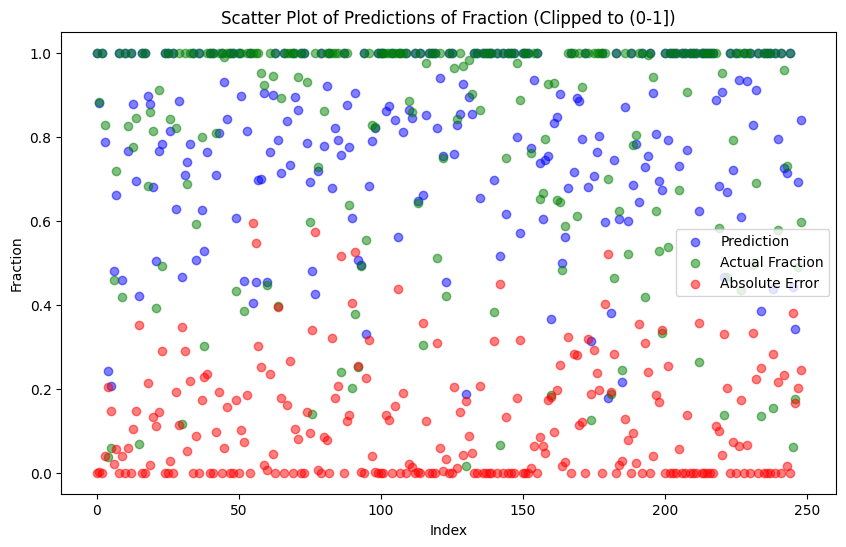

In [164]:
# Plot the distribution of the 'preds' array and 'fraction' column in one scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(preds)), np.clip(preds, 0, 2), color='blue', label='Prediction', alpha=0.5)
plt.scatter(range(len(y_test)), np.clip(y_test, 0, 2), color='green', label='Actual Fraction', alpha=0.5)
plt.scatter(range(len(y_test)), np.abs(preds-y_test), color='red', label='Absolute Error', alpha=0.5)
plt.xlabel('Index')
plt.ylabel('Fraction')
plt.title('Scatter Plot of Predictions of Fraction (Clipped to (0-1])')
plt.legend()
plt.show()


In [165]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# Initialize a regressor
reg = CatBoostRegressor()
reg.fit(X_train, y_train)

# Predict a point estimate (using the mean)
predictions = reg.predict(X_test)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, predictions))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, predictions))
print("R-squared (R^2):", r2_score(y_test, predictions))

Learning rate set to 0.039099
0:	learn: 0.2585799	total: 2.54ms	remaining: 2.54s
1:	learn: 0.2540141	total: 3.19ms	remaining: 1.59s
2:	learn: 0.2493842	total: 3.88ms	remaining: 1.29s
3:	learn: 0.2455133	total: 4.49ms	remaining: 1.12s
4:	learn: 0.2418416	total: 5.16ms	remaining: 1.03s
5:	learn: 0.2383100	total: 6.52ms	remaining: 1.08s
6:	learn: 0.2350076	total: 7.16ms	remaining: 1.01s
7:	learn: 0.2318194	total: 7.77ms	remaining: 964ms
8:	learn: 0.2285585	total: 8.37ms	remaining: 922ms
9:	learn: 0.2256365	total: 9.04ms	remaining: 895ms
10:	learn: 0.2232669	total: 9.75ms	remaining: 877ms
11:	learn: 0.2204911	total: 10.4ms	remaining: 860ms
12:	learn: 0.2180341	total: 11ms	remaining: 835ms
13:	learn: 0.2155589	total: 11.7ms	remaining: 821ms
14:	learn: 0.2132904	total: 12.8ms	remaining: 843ms
15:	learn: 0.2110951	total: 13.4ms	remaining: 827ms
16:	learn: 0.2086630	total: 14.1ms	remaining: 813ms
17:	learn: 0.2063603	total: 14.7ms	remaining: 801ms
18:	learn: 0.2043671	total: 15.3ms	remaining: 

In [166]:
# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.Explainer(reg)
shap_values = explainer(X)

# visualize the first prediction's explanation
# shap.plots.waterfall(shap_values[0])
shap.plots.force(shap_values[0, ...])


In [167]:
reg = LGBMRegressor()
reg.fit(X_train, y_train)

# Predict a point estimate (using the mean)
predictions = reg.predict(X_test)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, predictions))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, predictions))
print("R-squared (R^2):", r2_score(y_test, predictions))

Mean Squared Error (MSE): 0.03241916668840444
Mean Absolute Error (MAE): 0.12317634021942696
R-squared (R^2): 0.5656146832286157


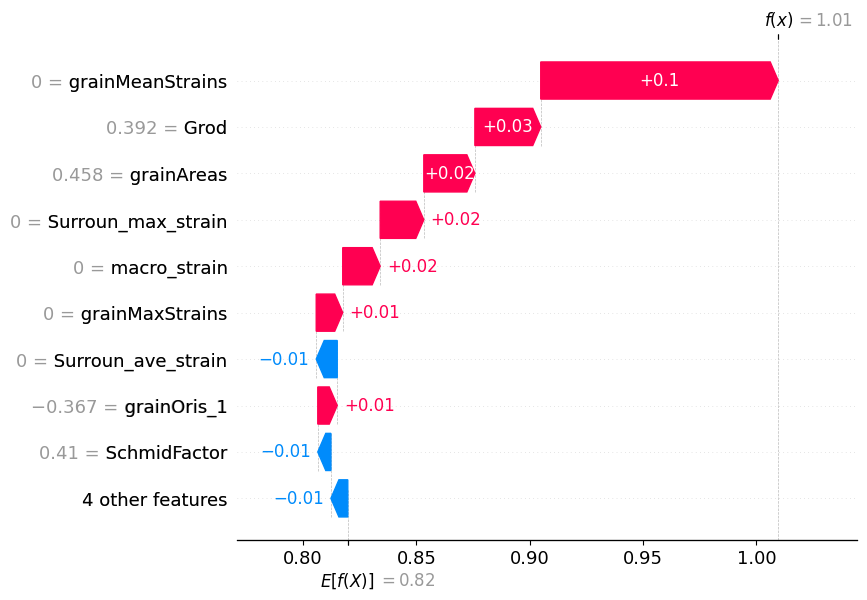

In [168]:
# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.Explainer(reg)
shap_values = explainer(X)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

In [ ]:
reg = RandomForestRegressor()
reg.fit(X_train, y_train)

# Predict a point estimate (using the mean)
predictions = reg.predict(X_test)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, predictions))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, predictions))
print("R-squared (R^2):", r2_score(y_test, predictions))

Mean Squared Error (MSE): 0.033342567195194066
Mean Absolute Error (MAE): 0.12047738957541809
R-squared (R^2): 0.5532420141373977


In [170]:
# Get feature importances
feature_importances = reg.feature_importances_
# Create a DataFrame for feature importances
feature_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Display the DataFrame
feature_importances_df

,Feature,Importance
1,grainMeanStrains,0.347100
0,grainAreas,0.120162
2,grainMaxStrains,0.106164
4,Surroun_max_strain,0.082094
6,Grod,0.069268
5,SchmidFactor,0.043398
10,grainOris_1,0.043119
11,grainOris_2,0.039208
9,grainOris_0,0.034265
12,grainOris_3,0.033784


In [171]:
reg = XGBRegressor()
reg.fit(X_train, y_train)

# Predict a point estimate (using the mean)
predictions = reg.predict(X_test)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, predictions))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, predictions))
print("R-squared (R^2):", r2_score(y_test, predictions))

Mean Squared Error (MSE): 0.035760129956789614
Mean Absolute Error (MAE): 0.12119355492828716
R-squared (R^2): 0.5208490234074417


In [172]:
from autogluon.tabular import TabularPredictor
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.columns

Index(['grainAreas', 'grainMeanStrains', 'grainMaxStrains',
       'Surroun_ave_strain', 'Surroun_max_strain', 'SchmidFactor', 'Grod',
       'macro_strain', 'macro_stress', 'grainOris_0', 'grainOris_1',
       'grainOris_2', 'grainOris_3', 'fraction'],
      dtype='object')

In [ ]:
reg = TabularPredictor(label='fraction', verbosity=1, eval_metric='r2').fit(train_data=train_data, time_limit=180, num_gpus=0)

# Predict a point estimate (using the mean)
predictions = reg.predict(X_test)


# test_data = X_test.copy()
# test_data['fraction'] = y_test.values

reg.evaluate(test_data)

No path specified. Models will be saved in: "AutogluonModels/ag-20250204_040120"
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	If 'regression' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
		ColumnTransformer.__init__() got an unexpected keyword argument 'force_int_remainder_cols'
Detailed Traceback:
Traceback (most recent call last):
  File "/Users/arthurzhao/anaconda3/envs/mlp/lib/python3.10/site-packages/autogluon/core/trainer/abstract_trainer.py", line 2106, in _train_and_save
    model = self._train_single(**model_fit_kwargs)
  File "/Users/arthurzhao/anaconda3/envs/mlp/lib/python3.10/site-packages/autogluon/core/trainer/abstract_trainer.py", line 1993, in _train_single
    model = model.fit(X=X, y=y, X_val=X_val, y_val=y_val, X_test=X_tes

{'r2': 0.5960732000495504,
 'root_mean_squared_error': -0.17362597192148874,
 'mean_squared_error': -0.030145978125681594,
 'mean_absolute_error': -0.11601013777272252,
 'pearsonr': 0.7734219921873928,
 'median_absolute_error': -0.06084257364273071}

In [177]:
reg.leaderboard(test_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,XGBoost,0.598944,0.582330,r2,0.004876,0.002164,0.465568,0.004876,0.002164,0.465568,1,True,9
1,WeightedEnsemble_L2,0.596073,0.617991,r2,0.013958,0.005981,2.054722,0.001161,0.000225,0.024123,2,True,11
2,CatBoost,0.589763,0.603270,r2,0.002554,0.001010,1.072403,0.002554,0.001010,1.072403,1,True,6
3,RandomForestMSE,0.588757,0.547883,r2,0.036676,0.027349,0.205380,0.036676,0.027349,0.205380,1,True,5
4,LightGBMXT,0.568124,0.568131,r2,0.004642,0.000906,0.877221,0.004642,0.000906,0.877221,1,True,3
5,LightGBM,0.556572,0.543782,r2,0.003912,0.000820,0.727275,0.003912,0.000820,0.727275,1,True,4
6,LightGBMLarge,0.547687,0.431230,r2,0.009096,0.002434,3.664522,0.009096,0.002434,3.664522,1,True,10
7,NeuralNetFastAI,0.545582,0.580959,r2,0.005367,0.002583,0.492628,0.005367,0.002583,0.492628,1,True,8
8,ExtraTreesMSE,0.523249,0.521596,r2,0.034062,0.044138,0.337722,0.034062,0.044138,0.337722,1,True,7
9,KNeighborsUnif,0.465035,0.430858,r2,0.013372,0.013861,0.002283,0.013372,0.013861,0.002283,1,True,1
